# Electron plasmon dispersion and DSF — `examples/electron_dsf`

This notebook runs the three inputs of this example directory and compares the results with
Diaw & Murillo, *Sci. Rep.* **7**, 15352 (2017), "A viscous quantum hydrodynamics model based on
dynamic density functional theory".

| input | what it does | paper |
|---|---|---|
| `rs1.86_g1.0.in` | `hydft_linear`: plasmon dispersion ω(q) and S(q,ω) at r_s = 1.86, Γ = 1.0 | Fig. 2(a) |
| `rs1.86_g0.7.in` | same at Γ = 0.7 | Fig. 2(b) |
| `rs1.86_g1.0_mode.in` | `hydft`: nonlinear single-mode simulation, probe of mode 3 (q = 0.471) | check of the linear result |

The linear response implemented in `src/linear/linear_response.f90` is

$$\chi(q,\omega) = \frac{-q^2 n_0}{-\omega^2 + q^2 n_0 K(q)/m - i\,q^2\bar\eta_l\,\omega},\qquad
\frac{S(q,\omega)}{n_0} = -\frac{1}{\pi n_0}\,\frac{\mathrm{Im}\,\chi}{1-e^{-\beta\hbar\omega}},$$

with the kernel $n_0K(q) = \lambda_{TF}^{-2} + \tfrac{\nu}{4}\lambda_{TF}^{-4}q^2 - \tfrac{1}{3\Gamma}n_0 C_{ee}(q)$
assembled from the Thomas–Fermi–Kirzhnits, Hartree and Ramakrishnan–Yussouff terms (paper Eqs. 19–22).
Units: lengths in $a$, times in $1/\omega_p$, $\eta_l$ in $m n_0 \omega_p a^2$. The paper's approximate dispersion is

$$\omega_q^2 \simeq \omega_p^2\Big[\lambda_{TF}^{-2}q^2 + \tfrac{\nu}{4}\lambda_{TF}^{-4}q^4 - \tfrac{q^2}{3\Gamma}n_0C_{ee}(q) - \tfrac{\eta_l^2 q^4}{2}\Big]\qquad\text{(Eq. 24)}$$

The code reports the exact root of the quadratic, $\omega = \sqrt{q^2 n_0 K - \eta_l^2 q^4/4} - i\,\eta_l q^2/2$; the last term of Eq. 24 has a factor 1/2 instead of 1/4, so both are shown below.

**What is not in the code:** the paper's electron viscosity $\eta_l(r_s,\Gamma)$ (supplement Eqs. 6–8: Conti–Vignale at T = 0
interpolated with the Stanton–Murillo fit). The example inputs use a constant `eta = 0.15` (η_l = 0.2). Section 3 reconstructs
the paper's viscosity model in Python and feeds it to the code through the `eta` input, so Figs. 1 and 2 of the paper can be attempted.

In [1]:
import os, sys, subprocess, pathlib, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

HERE = pathlib.Path.cwd().resolve()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / 'CMakeLists.txt').exists())
sys.path.insert(0, str(ROOT / 'python'))
from hydft_io import read_dispersion, read_dsf, read_probe, fit_damped_mode

BUILD = next((p for p in [ROOT / 'build-release', ROOT / 'build'] if (p / 'hydft_linear').exists()), None)
assert BUILD is not None, 'build the code first: cmake -S . -B build-release && cmake --build build-release'
OUT = HERE / 'out'; OUT.mkdir(exist_ok=True)      # *.dat outputs are git-ignored
print('repo  :', ROOT); print('binary:', BUILD)

# fixed categorical colours (blue, orange, aqua, yellow, magenta, violet)
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#4a3aa7']
plt.rcParams.update({'lines.linewidth': 1.6, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})

def run(exe, infile, cwd=OUT):
    t0 = time.time()
    r = subprocess.run([str(BUILD / exe), str(infile)], cwd=cwd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stdout[-2000:] + r.stderr[-2000:])
    print(f'{exe} {pathlib.Path(infile).name}: {time.time()-t0:.1f} s   | ' + r.stdout.strip().splitlines()[-1])
    return r.stdout

repo  : /Users/42d/Desktop/diaw_ddft
binary: /Users/42d/Desktop/diaw_ddft/build-release


## 1. The example inputs as they are

`hydft_linear` writes `<prefix>_dispersion.dat` (q, Re ω, Im ω, undamped ω₀ = q√(n₀K/m), S(q)) and
`<prefix>_dsf.dat` (S(q,ω)/n₀ for the `q_dsf` list).

In [2]:
for f in ['rs1.86_g1.0.in', 'rs1.86_g0.7.in']:
    run('hydft_linear', HERE / f)
ex = {g: read_dispersion(OUT / f'electron_rs1.86_g{g}_dispersion.dat') for g in ('1.0', '0.7')}
dsf_ex = {g: read_dsf(OUT / f'electron_rs1.86_g{g}_dsf.dat') for g in ('1.0', '0.7')}

hydft_linear rs1.86_g1.0.in: 3.0 s   | hydft_linear: wrote electron_rs1.86_g1.0_dispersion.dat and electron_rs1.86_g1.0_dsf.dat


hydft_linear rs1.86_g0.7.in: 2.4 s   | hydft_linear: wrote electron_rs1.86_g0.7_dispersion.dat and electron_rs1.86_g0.7_dsf.dat


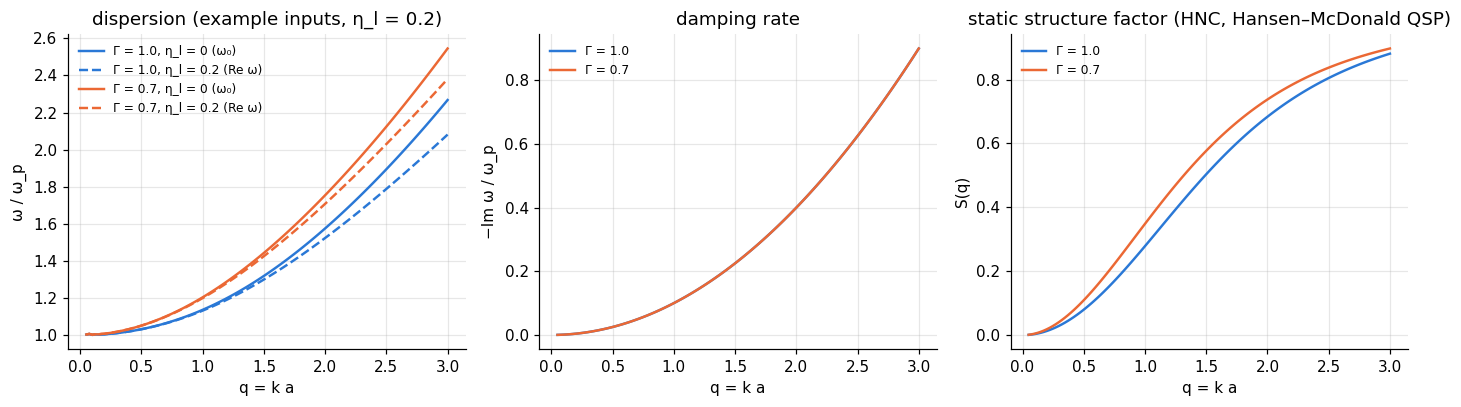

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for i, g in enumerate(('1.0', '0.7')):
    d = ex[g]
    ax[0].plot(d['q'], d['w0'], color=C[i], label=f'Γ = {g}, η_l = 0 (ω₀)')
    ax[0].plot(d['q'], d['re_w'], '--', color=C[i], label=f'Γ = {g}, η_l = 0.2 (Re ω)')
    ax[1].plot(d['q'], -d['im_w'], color=C[i], label=f'Γ = {g}')
    ax[2].plot(d['q'], d['S'], color=C[i], label=f'Γ = {g}')
ax[0].set(xlabel='q = k a', ylabel='ω / ω_p', title='dispersion (example inputs, η_l = 0.2)')
ax[1].set(xlabel='q = k a', ylabel='−Im ω / ω_p', title='damping rate')
ax[2].set(xlabel='q = k a', ylabel='S(q)', title='static structure factor (HNC, Hansen–McDonald QSP)')
for a in ax: a.legend(frameon=False, fontsize=8)
plt.tight_layout()

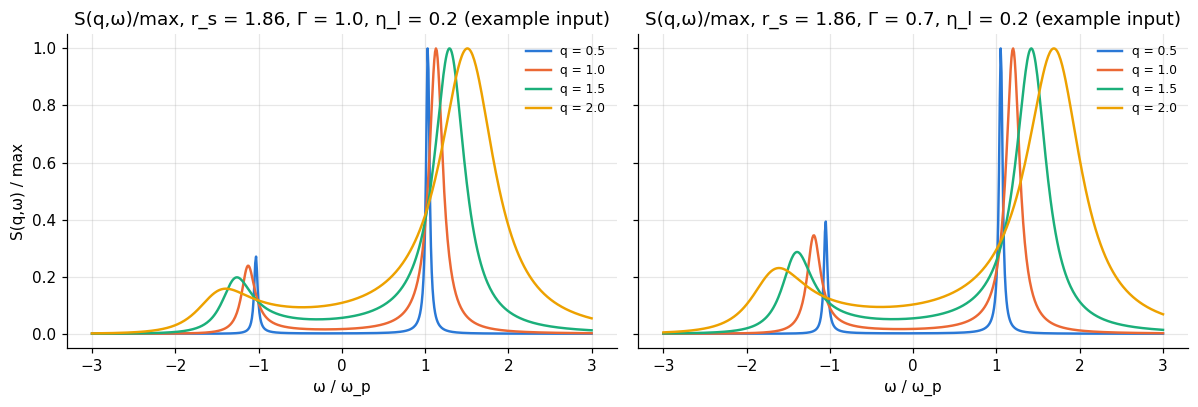

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for i, g in enumerate(('1.0', '0.7')):
    w, S, qs = dsf_ex[g]
    for j, q in enumerate(qs):
        ax[i].plot(w, S[:, j] / S[:, j].max(), color=C[j], label=f'q = {q:.1f}')
    ax[i].set(xlabel='ω / ω_p', title=f'S(q,ω)/max, r_s = 1.86, Γ = {g}, η_l = 0.2 (example input)')
    ax[i].legend(frameon=False, fontsize=8)
ax[0].set_ylabel('S(q,ω) / max')
plt.tight_layout()

## 2. Nonlinear single-mode simulation vs. the linear dispersion

`rs1.86_g1.0_mode.in` seeds mode 3 of a 40 a box (q = 3·2π/40 = 0.471) with amplitude 10⁻⁴ and probes it every step.
The frequency and damping fitted from the probe (zero crossings and peak envelope, `fit_damped_mode`) are compared with the
`hydft_linear` root at the same q.

hydft rs1.86_g1.0_mode.in: 2.7 s   | hydft: finished 740 steps, t =    100.0000  (      0.04 s)
                 Re ω/ω_p   Im ω/ω_p
simulation        1.02897   -0.02232
hydft_linear      1.02911   -0.02221
rel. diff.       1.38e-04   4.79e-03


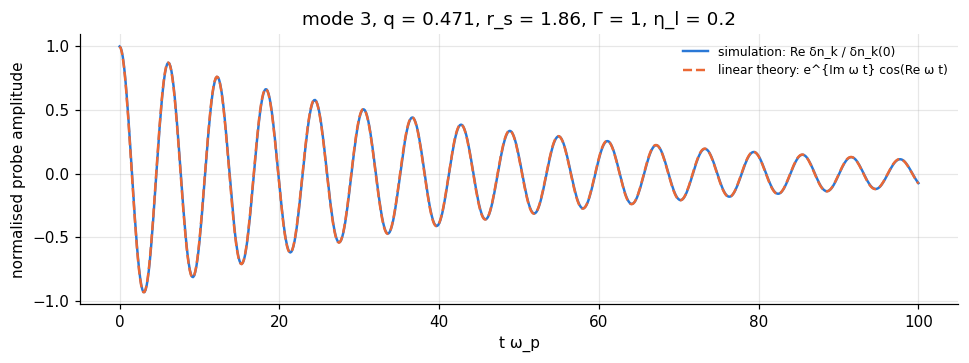

In [5]:
run('hydft', HERE / 'rs1.86_g1.0_mode.in')
t, dn, mom = read_probe(OUT / 'electron_rs1.86_g1.0_mode_probe.dat')
q_mode = 3 * 2 * np.pi / 40.0
w_sim, g_sim = fit_damped_mode(t, dn.real, t_start=0.1 * t[-1])
d = ex['1.0']
w_lin = np.interp(q_mode, d['q'], d['re_w']); g_lin = np.interp(q_mode, d['q'], d['im_w'])

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t, dn.real / dn.real[0], color=C[0], label='simulation: Re δn_k / δn_k(0)')
ax.plot(t, np.exp(g_lin * t) * np.cos(w_lin * t), '--', color=C[1], label='linear theory: e^{Im ω t} cos(Re ω t)')
ax.set(xlabel='t ω_p', ylabel='normalised probe amplitude', title=f'mode 3, q = {q_mode:.3f}, r_s = 1.86, Γ = 1, η_l = 0.2')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
print(f'{"":14s} {"Re ω/ω_p":>10s} {"Im ω/ω_p":>10s}')
print(f'{"simulation":14s} {w_sim:10.5f} {g_sim:10.5f}')
print(f'{"hydft_linear":14s} {w_lin:10.5f} {g_lin:10.5f}')
print(f'{"rel. diff.":14s} {abs(w_sim/w_lin-1):10.2e} {abs(g_sim/g_lin-1):10.2e}')

## 3. The paper's electron viscosity (supplement, Eqs. 6–8)

Implemented in `src/transport/stanton_murillo.f90` (`transport = 'electron_fit'`) and mirrored in
`python/stanton_murillo.py`; the Python version is used here to drive the parameter scans, and the Fortran
value is checked against it below.

* Conti–Vignale (T = 0), in units of $n m \omega_p a^2$:
  $\eta^*_{CV} = \dfrac{1}{\sqrt{3r_s}}\,\dfrac{1}{60\,r_s^{-3/2} + 80\,r_s^{-1} - 40\,r_s^{-2/3} + 62\,r_s^{-1/3}}$
* Stanton–Murillo (classical, *PRE* **93**, 043203, Eq. 75): $\eta^*_{SM} = \dfrac{5\sqrt{3\pi}}{36\,\Gamma^{5/2}K_{22}(g)}$,
  $g = \Gamma\,a/\lambda_{TF}$, with the $K_{22}$ fit of their Table IV (coefficients copied below).
  The supplement writes this as $5\sqrt{3\pi}/(18\Gamma^{5/2}\ln\Lambda_\eta)$ with $\ln\Lambda_\eta = 2K_{22}$.
* Interpolation: $\eta^*_l = \dfrac{4}{3}\,\dfrac{\eta^*_{CV} + \theta\,\eta^*_{SM}}{1+\theta}$, $\theta = T/T_F$, bulk viscosity ξ = 0.

The screening length is the finite-temperature Thomas–Fermi length $\lambda_{TF}^2 = 1/(4\pi e^2\,\partial n/\partial\mu)$
(the form used in `docs/equations.md`), which needs $\alpha_0$ from $n_0 = c_n I_{1/2}(\alpha_0)$.
The code's `eta` is the shear viscosity, so `eta = 3 η_l / 4`.

In [6]:
import stanton_murillo as smt     # python/stanton_murillo.py: K_nm fits, electron_units, electron_viscosity, ...

def eta_l(rs, gamma):
    return float(smt.electron_viscosity(rs, gamma)[0])

print(f'{"r_s":>5s} {"Γ":>5s} {"θ":>7s} {"λ_TF/a":>7s} {"g":>7s} {"η*_CV":>8s} {"η*_SM":>8s} {"η*_l":>8s}')
for rs, g in [(1.86, 1.0), (1.86, 0.7), (1.0, 0.2), (1.0, 0.6), (1.0, 0.8), (2.0, 0.2), (2.0, 0.6), (2.0, 0.8), (4.0, 0.2), (4.0, 0.6), (4.0, 0.8)]:
    u = smt.electron_units(rs, g)
    el, cv, sm = smt.electron_viscosity(rs, g)
    print(f'{rs:5.2f} {g:5.2f} {u["theta"]:7.3f} {u["lambda_tf"]:7.3f} {g/u["lambda_tf"]:7.3f} {cv:8.4f} {sm:8.3f} {el:8.3f}')

# the same number from the Fortran side: rs1.86_g1.0_fit.in uses transport = 'electron_fit'
log = run('hydft_linear', HERE / 'rs1.86_g1.0_fit.in')
print('\n'.join(l for l in log.splitlines() if 'transport' in l or 'eta_CV' in l or 'lambda_TF' in l))

  r_s     Γ       θ  λ_TF/a       g    η*_CV    η*_SM     η*_l
 1.86  1.00   1.010   0.647   1.545   0.0047    1.953    1.312
 1.86  0.70   1.443   0.741   0.945   0.0047    3.073    2.423
 1.00  0.20   2.715   1.329   0.151   0.0036   22.635   22.057
 1.00  0.60   0.905   0.850   0.706   0.0036    3.563    2.260
 1.00  0.80   0.679   0.780   1.026   0.0036    2.362    1.276
 2.00  0.20   5.430   1.304   0.153   0.0048   22.820   25.696
 2.00  0.60   1.810   0.785   0.765   0.0048    3.790    3.257
 2.00  0.80   1.358   0.697   1.148   0.0048    2.605    2.003
 4.00  0.20  10.860   1.296   0.154   0.0057   22.888   27.945
 4.00  0.60   3.620   0.760   0.790   0.0057    3.889    4.065
 4.00  0.80   2.715   0.664   1.204   0.0057    2.718    2.651


hydft_linear rs1.86_g1.0_fit.in: 2.4 s   | hydft_linear: wrote electron_rs1.86_g1.0_fit_dispersion.dat and electron_rs1.86_g1.0_fit_dsf.dat
  closure   newtonian   transport electron_fit   structure hnc
            lambda_TF/a =    0.6472
  transport electron_fit  eta =  0.98383  xi =  0.00000  eta_l =  1.31178  tau =    0.0000
            eta_CV =  0.00467  eta_SM =  1.95330


Check against the supplement's Fig. 4 (η*_l vs Γ for r_s = 2, 4, 6). Values read off that figure at Γ = 1 are
about 1.1, 1.2 and 1.3, and about 0.02 at Γ = 10.

reconstructed η*_l at Γ = 1: {2: 1.372, 4: 1.915, 6: 2.175}    at Γ = 10: {2: 0.022, 4: 0.053, 6: 0.089}


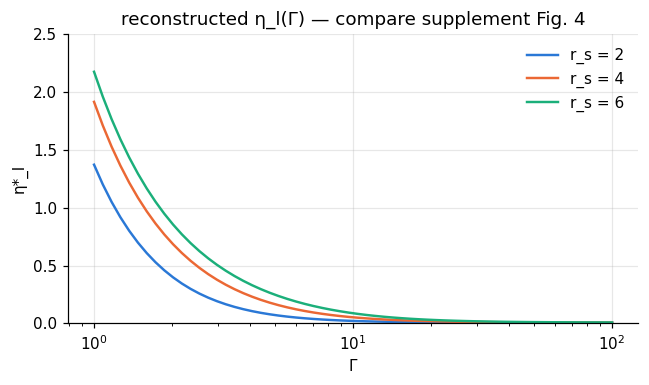

In [7]:
G = np.logspace(0, 2, 60)
fig, ax = plt.subplots(figsize=(6, 3.6))
for i, rs in enumerate((2, 4, 6)):
    ax.plot(G, [eta_l(rs, g) for g in G], color=C[i], label=f'r_s = {rs}')
ax.set(xscale='log', xlabel='Γ', ylabel='η*_l', title='reconstructed η_l(Γ) — compare supplement Fig. 4', ylim=(0, 2.5))
ax.legend(frameon=False)
plt.tight_layout()
print('reconstructed η*_l at Γ = 1:', {rs: round(eta_l(rs, 1.0), 3) for rs in (2, 4, 6)},
      '   at Γ = 10:', {rs: round(eta_l(rs, 10.0), 3) for rs in (2, 4, 6)})

## 4. Paper Fig. 2 — plasmon dispersion at r_s = 1.86, Γ = 1.0 and 0.7

Three runs per Γ, all through `hydft_linear`:

* **DDFT-QHD**: TFK + Hartree + $C_{ee}$ (HNC, Hansen–McDonald QSP) with η_l from Section 3,
* **DDFT-QHD, η_l = 0**: same kernel, no viscosity (the code's ω₀ column),
* **RPA**: `terms = 'tf,gradient,hartree'` and η_l = 0, i.e. $C_{ee} = -\beta v$ (Bohm–Gross for the isothermal plasma).

The DSF peak positions ($\arg\max_\omega S(q,\omega)$ for ω > 0) are added as markers; the paper says the peak "corresponds to" Eq. 24.

In [8]:
def write_input(name, rs, gamma, eta, terms='tf,gradient,hartree,ry', structure='hnc', q=(0.02, 2.0, 100),
                q_dsf=(0.5,), omega_max=3.0, nomega=600, nr=32768, rmax=320.0, tfk_gamma=1/9):
    qd = ', '.join(f'{x:.4f}' for x in q_dsf)
    text = f'''&grid nx = 64, lx = 40.0 /
&species kind = 'electron', rs = {rs}, gamma = {gamma}, terms = '{terms}', tfk_gamma = {tfk_gamma:.9f},
         structure = '{structure}', closure = 'newtonian', transport = 'constant', eta = {eta:.6f}, xi = 0.0 /
&hnc nr = {nr}, rmax = {rmax} /
&linear qmin = {q[0]}, qmax = {q[1]}, nq = {q[2]}, omega_max = {omega_max}, nomega = {nomega}, q_dsf = {qd} /
&output prefix = '{name}' /
'''
    (OUT / f'{name}.in').write_text(text)
    return OUT / f'{name}.in'

def linear(name, **kw):
    run('hydft_linear', write_input(name, **kw))
    d = read_dispersion(OUT / f'{name}_dispersion.dat')
    w, S, qs = read_dsf(OUT / f'{name}_dsf.dat')
    return dict(disp=d, w=w, S=S, qs=qs)

def dsf_peaks(r):
    w, S = r['w'], r['S']
    m = w > 0
    return np.array([w[m][np.argmax(S[m, j])] for j in range(S.shape[1])])

q_peaks = (0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6)
fig2 = {}
for gamma in (1.0, 0.7):
    el = eta_l(1.86, gamma)
    fig2[gamma] = dict(
        eta_l=el,
        qhd=linear(f'fig2_g{gamma}_qhd', rs=1.86, gamma=gamma, eta=0.75 * el, q_dsf=q_peaks, nomega=3000),
        eta0=linear(f'fig2_g{gamma}_eta0', rs=1.86, gamma=gamma, eta=0.0, q_dsf=q_peaks, nomega=3000),
        rpa=linear(f'fig2_g{gamma}_rpa', rs=1.86, gamma=gamma, eta=0.0, terms='tf,gradient,hartree', structure='none'),
    )

hydft_linear fig2_g1.0_qhd.in: 2.4 s   | hydft_linear: wrote fig2_g1.0_qhd_dispersion.dat and fig2_g1.0_qhd_dsf.dat


hydft_linear fig2_g1.0_eta0.in: 2.4 s   | hydft_linear: wrote fig2_g1.0_eta0_dispersion.dat and fig2_g1.0_eta0_dsf.dat
hydft_linear fig2_g1.0_rpa.in: 0.1 s   | hydft_linear: wrote fig2_g1.0_rpa_dispersion.dat and fig2_g1.0_rpa_dsf.dat


hydft_linear fig2_g0.7_qhd.in: 2.4 s   | hydft_linear: wrote fig2_g0.7_qhd_dispersion.dat and fig2_g0.7_qhd_dsf.dat


hydft_linear fig2_g0.7_eta0.in: 2.4 s   | hydft_linear: wrote fig2_g0.7_eta0_dispersion.dat and fig2_g0.7_eta0_dsf.dat
hydft_linear fig2_g0.7_rpa.in: 0.1 s   | hydft_linear: wrote fig2_g0.7_rpa_dispersion.dat and fig2_g0.7_rpa_dsf.dat


Γ = 1.0: η_l = 1.312;  Eq. 24 reaches ω = 0 at q ≈ 1.13;  exact root becomes overdamped at q ≈ 1.41;  ω(q→0) = 1.0081
Γ = 0.7: η_l = 2.423;  Eq. 24 reaches ω = 0 at q ≈ 0.83;  exact root becomes overdamped at q ≈ 1.01;  ω(q→0) = 1.0081


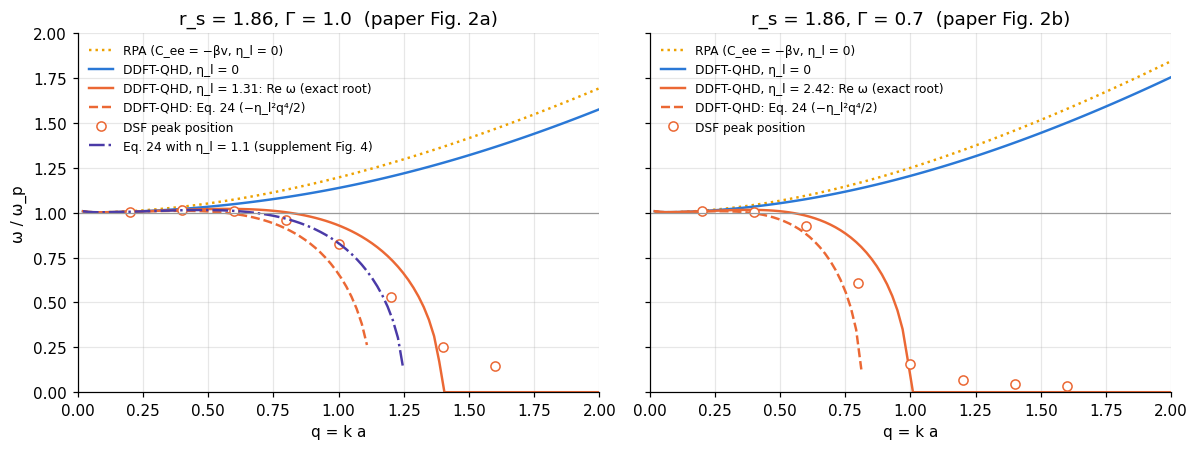

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for i, gamma in enumerate((1.0, 0.7)):
    r, el = fig2[gamma], fig2[gamma]['eta_l']
    q = r['qhd']['disp']['q']
    w0 = r['eta0']['disp']['w0']
    w24 = np.sqrt(np.clip(w0**2 - el**2 * q**4 / 2, 0, None))      # paper Eq. 24 as printed
    ax[i].plot(q, r['rpa']['disp']['w0'], ':', color=C[3], label='RPA (C_ee = −βv, η_l = 0)')
    ax[i].plot(q, w0, color=C[0], label='DDFT-QHD, η_l = 0')
    ax[i].plot(q, r['qhd']['disp']['re_w'], color=C[1], label=f'DDFT-QHD, η_l = {el:.2f}: Re ω (exact root)')
    ax[i].plot(q, np.where(w24 > 0, w24, np.nan), '--', color=C[1], label='DDFT-QHD: Eq. 24 (−η_l²q⁴/2)')
    pk = dsf_peaks(r['qhd'])
    ax[i].plot(r['qhd']['qs'], pk, 'o', ms=6, mfc='white', mec=C[1], label='DSF peak position')
    if gamma == 1.0:   # value read off the supplement's Fig. 4 at r_s = 2, Γ = 1
        w24b = np.sqrt(np.clip(w0**2 - 1.1**2 * q**4 / 2, 0, None))
        ax[i].plot(q, np.where(w24b > 0, w24b, np.nan), '-.', color=C[5], label='Eq. 24 with η_l = 1.1 (supplement Fig. 4)')
    ax[i].set(xlabel='q = k a', xlim=(0, 2), ylim=(0, 2), title=f'r_s = 1.86, Γ = {gamma}  (paper Fig. 2{"ab"[i]})')
    ax[i].axhline(1, color='0.6', lw=0.8)
    ax[i].legend(frameon=False, fontsize=8, loc='upper left')
ax[0].set_ylabel('ω / ω_p')
plt.tight_layout()

for gamma in (1.0, 0.7):
    r, el = fig2[gamma], fig2[gamma]['eta_l']
    q = r['qhd']['disp']['q']; w0 = r['eta0']['disp']['w0']
    q24 = q[np.argmax(w0**2 - el**2 * q**4 / 2 < 0)] if np.any(w0**2 - el**2 * q**4 / 2 < 0) else np.nan
    qex = q[np.argmax(r['qhd']['disp']['re_w'] <= 1e-6)] if np.any(r['qhd']['disp']['re_w'] <= 1e-6) else np.nan
    print(f'Γ = {gamma}: η_l = {el:.3f};  Eq. 24 reaches ω = 0 at q ≈ {q24:.2f};  exact root becomes overdamped at q ≈ {qex:.2f};'
          f'  ω(q→0) = {w0[0]:.4f}')

### Reading Fig. 2 of the paper

* The **η_l = 0** and **RPA** curves are parameter-free: both start at ω_p and the RPA curve rises as the Bohm–Gross/quantum
  $q^2$ and $q^4$ terms, while $C_{ee}$ from HNC pulls the correlated curve below it (negative dispersion for Γ ≳ 1).
* The **viscous** curve bends over and reaches ω = 0 where $\eta_l^2 q^4/2 = q^2 n_0 K$. In the paper this happens near
  q ≈ 1.35 (Γ = 1.0) and q ≈ 1.1 (Γ = 0.7); the values found here with the reconstructed η_l are printed above.
  The cutoff position scales as $\eta_l^{-1/2}$, so it is a direct test of the viscosity used.
* The DSF peak does not follow the exact root closely once damping is strong: the maximum of $S(q,\omega)$ stays at a
  finite ω after the root becomes purely imaginary, because the Bose factor and the $\omega$-dependence of the denominator shift it.
* Note that the panel labels in the paper's Fig. 2 read r_s = 1.0 and 2.0 while the caption says r_s = 1.86; the runs here use r_s = 1.86.

## 5. Paper Fig. 1 — DSF for Γ = 0.2, 0.6, 0.8 and r_s = 1, 2, 4 at q = 0.14, 0.32, 0.64

Nine `hydft_linear` runs with η_l from the Section 3 model; each panel is normalised by its maximum as in the paper.

In [10]:
gammas, rss, qs1 = (0.2, 0.6, 0.8), (1.0, 2.0, 4.0), (0.14, 0.32, 0.64)
fig1 = {}
for rs in rss:
    for gamma in gammas:
        el = eta_l(rs, gamma)
        fig1[rs, gamma] = (el, linear(f'fig1_rs{rs:.0f}_g{gamma}', rs=rs, gamma=gamma, eta=0.75 * el,
                                      q=(0.1, 1.0, 9), q_dsf=qs1, omega_max=2.0, nomega=800))

hydft_linear fig1_rs1_g0.2.in: 2.4 s   | hydft_linear: wrote fig1_rs1_g0.2_dispersion.dat and fig1_rs1_g0.2_dsf.dat


hydft_linear fig1_rs1_g0.6.in: 2.4 s   | hydft_linear: wrote fig1_rs1_g0.6_dispersion.dat and fig1_rs1_g0.6_dsf.dat


hydft_linear fig1_rs1_g0.8.in: 2.5 s   | hydft_linear: wrote fig1_rs1_g0.8_dispersion.dat and fig1_rs1_g0.8_dsf.dat


hydft_linear fig1_rs2_g0.2.in: 2.3 s   | hydft_linear: wrote fig1_rs2_g0.2_dispersion.dat and fig1_rs2_g0.2_dsf.dat


hydft_linear fig1_rs2_g0.6.in: 2.4 s   | hydft_linear: wrote fig1_rs2_g0.6_dispersion.dat and fig1_rs2_g0.6_dsf.dat


hydft_linear fig1_rs2_g0.8.in: 2.4 s   | hydft_linear: wrote fig1_rs2_g0.8_dispersion.dat and fig1_rs2_g0.8_dsf.dat


hydft_linear fig1_rs4_g0.2.in: 2.3 s   | hydft_linear: wrote fig1_rs4_g0.2_dispersion.dat and fig1_rs4_g0.2_dsf.dat


hydft_linear fig1_rs4_g0.6.in: 2.4 s   | hydft_linear: wrote fig1_rs4_g0.6_dispersion.dat and fig1_rs4_g0.6_dsf.dat


hydft_linear fig1_rs4_g0.8.in: 2.4 s   | hydft_linear: wrote fig1_rs4_g0.8_dispersion.dat and fig1_rs4_g0.8_dsf.dat


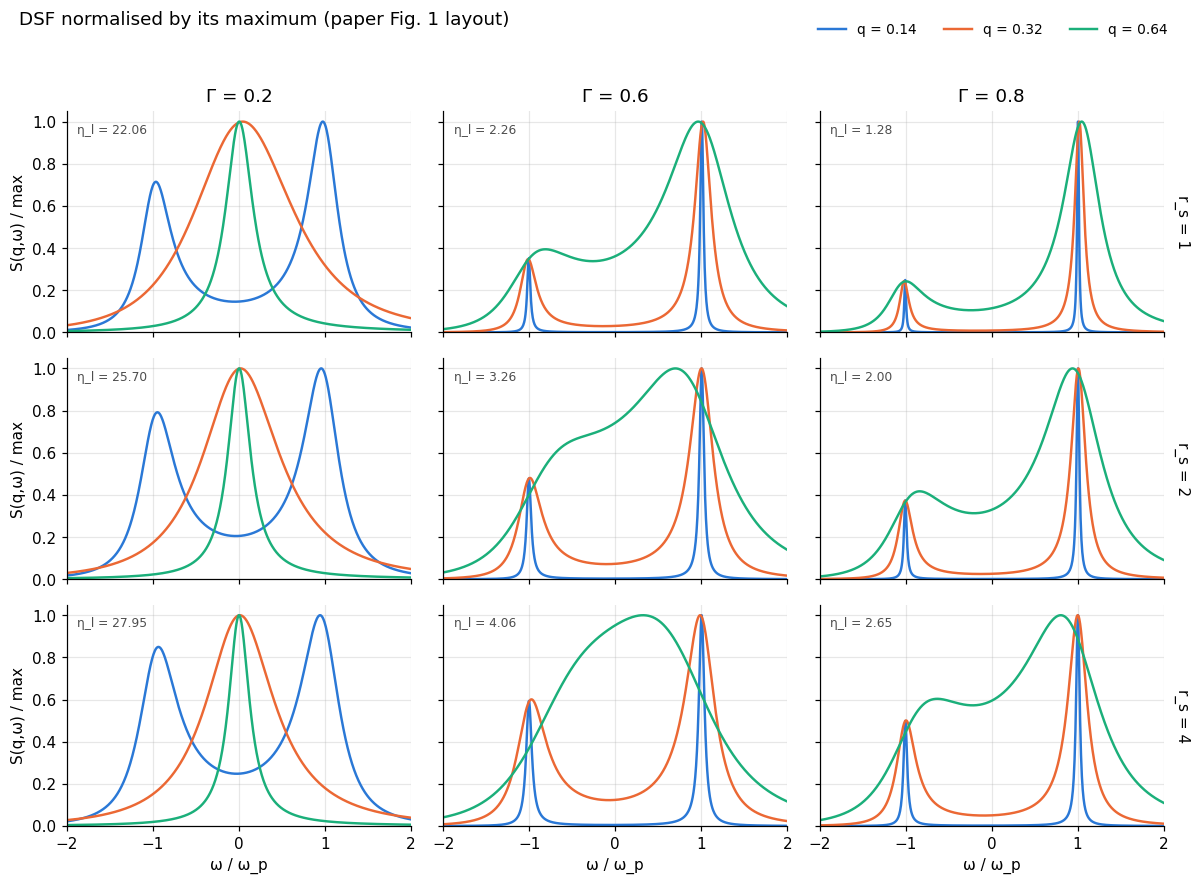

In [11]:
fig, ax = plt.subplots(3, 3, figsize=(11, 8), sharex=True, sharey=True)
for i, rs in enumerate(rss):
    for j, gamma in enumerate(gammas):
        el, r = fig1[rs, gamma]
        for k, q in enumerate(r['qs']):
            ax[i, j].plot(r['w'], r['S'][:, k] / r['S'][:, k].max(), color=C[k], label=f'q = {q:.2f}')
        ax[i, j].text(0.03, 0.9, f'η_l = {el:.2f}', transform=ax[i, j].transAxes, fontsize=8, color='0.3')
        if i == 0: ax[i, j].set_title(f'Γ = {gamma}')
        if j == 2: ax[i, j].text(1.03, 0.5, f'r_s = {rs:.0f}', transform=ax[i, j].transAxes, rotation=-90, va='center')
        if i == 2: ax[i, j].set_xlabel('ω / ω_p')
        if j == 0: ax[i, j].set_ylabel('S(q,ω) / max')
ax[0, 0].set(xlim=(-2, 2), ylim=(0, 1.05))
h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, frameon=False, fontsize=9, ncol=3, loc='upper right', bbox_to_anchor=(0.98, 1.0))
fig.suptitle('DSF normalised by its maximum (paper Fig. 1 layout)', x=0.02, ha='left', y=1.0)
plt.tight_layout(rect=(0, 0, 1, 0.97))

### Reading Fig. 1 of the paper

* The plasmon peak sits near ω_p for q = 0.14 and 0.32 in every panel, with little dependence on r_s, as in the paper.
* The peak width grows with q as $\eta_l q^2$ and shrinks with Γ (η_l ∝ Γ^{-5/2} in the classical part), so the Γ = 0.2
  column is broad and the Γ = 0.8 column is sharp; the q = 0.64 curve at Γ = 0.6 becomes a broad hump, as in the paper's panel (b).
* The Stokes/anti-Stokes asymmetry is the Bose factor $e^{\beta\hbar\omega}$ with $\beta\hbar\omega_p = \sqrt{3\Gamma^2/r_s}$; it is
  visible at r_s = 1 and small at r_s = 4.
* How closely the widths match depends entirely on η_l, which is the least certain input (Section 3).

## 6. Sensitivity to the HNC box

The original example inputs used `&hnc nr = 8192, rmax = 80`. The correlation kernel
$c_{cor}(k) = c(k) + \beta v(k)$ is the difference of two terms that both diverge as $1/k^2$, so the small-q part of the
dispersion is sensitive to the k-resolution π/rmax of the HNC transform. This is why the inputs now use `nr = 32768, rmax = 320`.

hydft_linear hnc_rmax80.in: 0.4 s   | hydft_linear: wrote hnc_rmax80_dispersion.dat and hnc_rmax80_dsf.dat


hydft_linear hnc_rmax160.in: 0.7 s   | hydft_linear: wrote hnc_rmax160_dispersion.dat and hnc_rmax160_dsf.dat


hydft_linear hnc_rmax320.in: 2.8 s   | hydft_linear: wrote hnc_rmax320_dispersion.dat and hnc_rmax320_dsf.dat


hydft_linear hnc_rmax640.in: 1.0 s   | hydft_linear: wrote hnc_rmax640_dispersion.dat and hnc_rmax640_dsf.dat


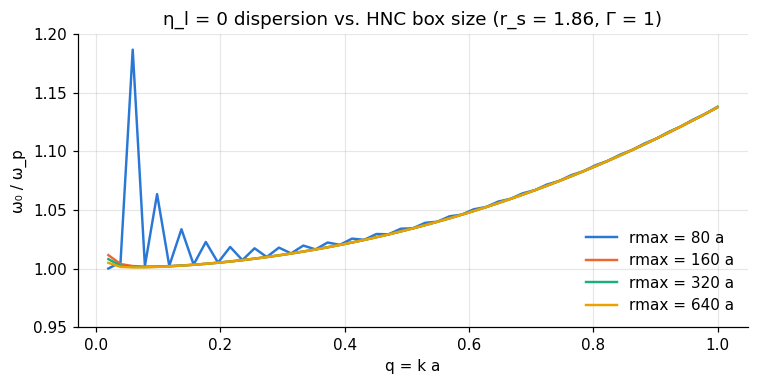

In [12]:
runs = {}
for nr, rmax in [(8192, 80.0), (16384, 160.0), (32768, 320.0), (65536, 640.0)]:
    runs[rmax] = linear(f'hnc_rmax{rmax:.0f}', rs=1.86, gamma=1.0, eta=0.0, q=(0.02, 1.0, 50), nr=nr, rmax=rmax, nomega=10)
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, (rmax, r) in enumerate(runs.items()):
    ax.plot(r['disp']['q'], r['disp']['w0'], color=C[i], label=f'rmax = {rmax:.0f} a')
ax.set(xlabel='q = k a', ylabel='ω₀ / ω_p', ylim=(0.95, 1.2), title='η_l = 0 dispersion vs. HNC box size (r_s = 1.86, Γ = 1)')
ax.legend(frameon=False)
plt.tight_layout()

## 7. Summary

**Reproduced without free parameters**

* Nonlinear single-mode simulation vs. linear theory: frequency agrees to ~10⁻⁴, damping to ~0.5 % (Section 2).
* Fig. 2, η_l = 0 and RPA curves: both start at ω_p; the HNC $C_{ee}$ lowers the dispersion below RPA and the RPA curve
  rises with the $\lambda_{TF}^{-2}q^2$ and $\nu\lambda_{TF}^{-4}q^4/4$ terms. The paper's curves rise faster than these
  (its RPA reaches 2 ω_p by q ≈ 1.2, here by q ≈ 2.5): `docs/equations.md` notes that the constants printed in the paper's
  Eq. 20 for $\lambda_{TF}$ and ν were re-derived for the code, so the $q^2$ coefficient is the place to look.
* Fig. 1: peak positions near ±ω_p, the Bose asymmetry $e^{-\beta\hbar\omega_p}$ with $\beta\hbar\omega_p = \Gamma\sqrt{3/r_s}$
  (0.25 at r_s = 1, Γ = 0.8; 0.5 at r_s = 4), the narrowing with Γ and the broad q = 0.64 hump at Γ = 0.6 all match the paper.

**Reproduced up to the viscosity**

* The reconstructed η_l (supplement Eqs. 6–8 + Stanton–Murillo $K_{22}$ fit, Thomas–Fermi screening) is consistently
  about 20–25 % above the supplement's Fig. 4 (1.37 vs ≈ 1.1 at r_s = 2, Γ = 1; 1.9 vs ≈ 1.2 at r_s = 4).
  The same factor explains the two remaining differences: the Fig. 2 cutoff (Eq. 24 with η_l = 1.1 reaches ω = 0 at q ≈ 1.24,
  close to the paper's ≈ 1.35, versus q ≈ 1.13 with η_l = 1.31) and the Γ = 0.2, q = 0.32 curve of Fig. 1, which the paper
  shows with two peaks at ω ≈ ±0.5 (η_l ≈ 17) while η_l ≈ 22 here puts it just past critical damping.
  The likely cause is the screening length entering g = Γ a/λ (the supplement only says "the Thomas–Fermi length"); this should be
  checked against the original scripts. Once settled, the model belongs in `src/transport/transport.f90` as `transport = 'electron_fit'`.
* Eq. 24 as printed ($-\eta_l^2q^4/2$) and the exact root of the code's quadratic ($-\eta_l^2q^4/4$) differ visibly for q ≳ 0.8;
  the DSF maximum follows neither once the mode is overdamped.

**Numerics**

* The correlation kernel $c(k) + \beta v(k)$ is a difference of two $1/k^2$ terms, so the small-q dispersion needs a large HNC box:
  `rmax = 80` gave ±15 % noise below q ≈ 0.3, `rmax ≥ 160` (nr ≥ 16384) removes it. The example inputs now use `nr = 32768, rmax = 320`.
  A residual ω(q → 0) ≈ 1.008 ω_p at the very first k-points remains.